# Merwedebrug — 4x5 Optimization Example

This notebook is a worked example for a multi-objective optimization
for an artificial-reef design problem. It shows how to:

- Define design variables and bounds
- Specify multiple objective functions and preference mappings
- Build constraints
- Run a Genetic Algorithm (GA) using two (potentially three) aggregation paradigms
- Visualize preference functions and optimization results


## Problem

During the 1990s, the city of Gold Coast experienced significant beach erosion, threatening one of its most valuable assets. The local economy relied heavily on beach-related recreation and surfing tourism, making the loss of beach width a major concern for the city council.

To address the erosion problem, several coastal protection measures were considered, including a multipurpose artificial reef, artificial seaweed, groynes, and offshore breakwaters. Each alternative offered different advantages and disadvantages in terms of cost, coastal protection, environmental impact, aesthetics, and recreational value.

Ultimately, the artificial reef was selected as the preferred solution. In addition to providing coastal protection, it offered several unique benefits: it remained largely invisible from the shoreline, created new habitat for marine life, and generated high-quality surfing waves. These additional functions made the artificial reef an attractive multipurpose solution compared with the more conventional alternatives.

## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully, your environment must include the required dependencies. The virtual environment provided in MUDE, called **`mude-base`**, is sufficient for this purpose.

In addition, several plotting settings are defined, and the local optimisation code is imported. It is important that the provided zip file is extracted in its entirety, as the structure of the directory is required for the imports to work correctly.

The local module `genetic_algorithm_pfm` is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`

In [5]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 

# Define default plotting parameters
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

## Design Variables and Bounds

The artificial reef geometry is parameterized using four continuous design variables:

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Width of bridge deck per bridge | m | Continuous |
| `x2` | Height of steel arch | m | Continuous |
| `x3` | Length of bascule bridge span | m | Continuous |
| `x4` | Clearance height | m w.r.t. NAP| Continuous | 
| `x5` | Span of the steel arch | m | Continuous | 

**Note:** In the code, design variables are defined only by their type (discrete or continuous) and their bounds — *not* by their physical meaning. Before implementing, it is good practice to write down your choice of design variables on paper, including their units and expected ranges. This helps avoid errors and builds physical intuition for the problem.



Each variable is assigned bounds that reflect physically meaningful and feasible values for a real-world reef design. These are defined below.

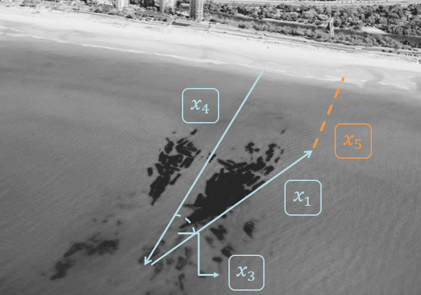

`X_irl` contains a reference design based on a real-world installation, which will later be used for comparison against the optimised solutions. Its design variable values are:

In [6]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('x1', 'Width of bridge deck per bridge', 'm'),
    ('x2', 'Height of steel arch', 'm'),
    ('x3', 'Length of bascule bridge span', 'm'),
    ('x4', 'Clearance height arch part', 'm w.r.t. NAP'),
    ('x5', 'Clearance height bascule part', 'm w.r.t. NAP'),
    ('x6', 'Distance to shore', 'm')
)

# set bounds for all variables
b1 = [10, 25]       # x1
b2 = [35, 65]       # x2
b3 = [40, 66]       # x3
b4 = [10, 15]       # x4
b5 = [9, 12]       # x5
b6 = [200, 287]       # x6

bounds = [b1, b2, b3, b4, b5, b6]

X_irl = [18, 50, 13.3, 10.45, 258.8]
plot_irl = True  # Can be true or False, depending on whether you want to plot the IRL point or not

## Constraints

Constraints ensure that all solutions remain physically feasible. For this artificial reef model, one physical constraint is considered: **the reef has a minimum distance from the beach**. This constraint, `constraint_1`, is a simple geometric relation corresponding to the distance `x5` shown in the figure above. A constraint function may use as many or as few design variables as necessary.

Each *constraint function* must be expressed as an algebraic expression of the form:

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

> **Important:** The constraint function should return only the value of $g(\mathbf{x})$ — do *not* encode the inequality inside the function. The inequality type (`'ineq'`) is specified separately when registering the constraint in `cons`, and the optimiser handles the comparison.

The constraints are registered as follows:

```python
cons = [['ineq', constraint_1], ['ineq', constraint_2]]
```

In [7]:
def constraint_1(variables):
    #Total height of the bridge 
    x1 = variables[:, 0] # Width of bridge deck per bridge
    x2 = variables[:, 1] # Height of steel arch
    x3 = variables[:, 2] # Length of bascule bridge span
    x4 = variables[:, 3] # Clearance height arch-part
    x5 = variables[:, 4] # Clearance height bascule-part
    x6 = variables[:, 5] # Span of the steel arch
        
    max_height = 50     # minimum height of total bridge [m]
    
    return x4 + x2 - max_height <= 0

def constraint_2(variables):
    #Bascule span smaller than arc span
    x1 = variables[:, 0] # Width of bridge deck per bridge
    x2 = variables[:, 1] # Height of steel arch
    x3 = variables[:, 2] # Length of bascule bridge span
    x4 = variables[:, 3] # Clearance height arch-part
    x5 = variables[:, 4] # Clearance height bascule-part
    x6 = variables[:, 5] # Span of the steel arch

    return x3 - x6 <= 0 

def constraint_3(variables):
    #Clearance height smaller than height of steel arch
    x1 = variables[:, 0] # Width of bridge deck per bridge
    x2 = variables[:, 1] # Height of steel arch
    x3 = variables[:, 2] # Length of bascule bridge span
    x4 = variables[:, 3] # Clearance height arch-part
    x5 = variables[:, 4] # Clearance height bascule-part
    x6 = variables[:, 5] # Span of the steel arch

    return x4 - x2 <= 0 
        
def constraint_4(variables):
    #h < L/5, limits costs and h > L/8, limits structural moments in arc
    x1 = variables[:, 0] # Width of bridge deck per bridge
    x2 = variables[:, 1] # Height of steel arch
    x3 = variables[:, 2] # Length of bascule bridge span
    x4 = variables[:, 3] # Clearance height arch-part
    x5 = variables[:, 4] # Clearance height bascule-part
    x6 = variables[:, 5] # Span of the steel arch

    return (x2/x6 - 1/5 <= 0) & (1/8 - x2/x6 <= 0)

def constraint_5(variables):
    #6 clearance height of new bridge is equal to clearance height of old bridge = 13.3m
    x1 = variables[:, 0] # Width of bridge deck per bridge
    x2 = variables[:, 1] # Height of steel arch
    x3 = variables[:, 2] # Length of bascule bridge span
    x4 = variables[:, 3] # Clearance height arch-part
    x5 = variables[:, 4] # Clearance height bascule-part
    x6 = variables[:, 5] # Span of the steel arch

    min_dis_clearance = 13.3

    return min_dis_clearance - x4 <= 0

cons = [['ineq', constraint_1], ['ineq', constraint_2], ['ineq', constraint_3], ['ineq', constraint_4], ['ineq', constraint_5]]

## Objective Functions

This model optimises five objectives, each representing a different stakeholder identified during the preceding stakeholder analysis. The table below summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| City council | Construction cost | $ |
| Surfing community | Ride length | m |
| Research community | Sediment trapping | m³/yr |
| Local community | Safety | accidents/yr |
| Tourism | Economic growth | $ |

Each objective is then expressed as a function of the design variables. Where needed, physical constants are introduced to make the units consistent — reasonable estimates are sufficient.

In [14]:
# Define objective functions

def objective_function_1(x1, x2, x3, x4, x5, x6):
    """
    operational safety function
    
    :return: expected accidents per year.
    """
    AADT = 90000    # average daily traffic
    f = 0.05      # accidents per million vehicle km 

    return ((AADT * 365 * (x3 + x6) * f) / 1000000)


def objective_function_2(x1, x2, x3, x4, x5, x6):
    """
    Life-cycle costs
    
    :return: costs in euro
    """
    p_beton = 30                            # price in euro for m2 concrete
    p_staal = 400                           # price in euro for m2 steel
    L_boog = x6 + (8 * x2**2)/(3 * x6)      # length steel arch

    return (x1 * x6 + x1 * x3) * p_beton + L_boog * p_staal


def objective_function_3(x1, x2, x3, x4, x5, x6):
    """
    Accesibility
    
    :return: vehicle delay in hours per year
    """
    n_s = 350       # amount of ships
    n_c = 4000      # amount of cars
    c = 5           #coefficient redundancy bridge opening
    t = 0.25        # time of bridge opening (hours)
    T = 1/60        # time for passing the bridge without delay (hours)  
    alpha = 4       #first coefficient formula   
    beta = 0.15     #second coefficient formula

    return ((1-(x4/15)*(1/3) / c) * n_s * 365 * n_c * t + T * alpha * (n_c / (2000 * ((x1 - 3.5)/3.5)))*beta)


def objective_function_4(x1, x2, x3, x4, x5, x6):
    """
    Construction nuisance
    
    :return: disruption days per year
    """
    gamma = 7    # coefficient for baseline disruption days (minimum 1 week)
 
    return (gamma * (1/3 * (x1/10) + 1/3 * (x3/40)*2 + 1/3 * (x4/10)*(1/3)))


def objective_function_5(x1, x2, x3, x4, x5, x6):
    """
    Visual impact
    
    :return: impactscore 0 - 100
    """
    # The lower the score, the more favourable the visual impact

    return (((x2 + x4) * x1 * x6) / ((65 + 15) * 25 * 287)) * 100

def objective_function_6(x1, x2, x3, x4, x5, x6):
    """
    Construction safety
    
    :return: expected accidents during construction
    """
    epsilon = 1     #baseline for the amount of accidents

    return epsilon * (0.5 * ((x1 * (x3 + x6)) / (10*(40 + 287))) + 0.5 * (x2/35))

def objective_function_7(x1, x2, x3, x4, x5, x6):
    """
    Navigability
    
    :return: delay hours per year
    """
    t_1 = 0.05          #baseline delay due to span of bridge
    t_2 = 0.5           #expected delay due to opening bridge
    n = 350 * 365       #amount of ships passing each year

    return t_1 * (287 / x6)*2 * (x4 / 15) * (1/3) * n + t_2 * (1 - (x4 / 15)*(1/3)) * n

# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_function_1, "Operational Safety",    "accidents/year",                       "Rijkswaterstaat"),
    (objective_function_2, "Life-cycle costs",      "euro",                                 "MIWM"),
    (objective_function_3, "Accessibility",         "Vehicle-delay hours per year",         "Municipalities"),
    (objective_function_4, "Construction nuisance", "Disruption days per year",             "Road users"),
    (objective_function_5, "Visual impact",         "Impact score",                         "Residents"),
    (objective_function_6, "Construction safety",   "Expected accidents during construction","Contractor"),
    (objective_function_7, "Navigability",          "Vessel-delay hours per year",           "Shipping sector")
]


While developing the objectuve functions, it can be helpful to investigate their behavior. Here the attainable minimum and maximum of each objective is computed. These ranges serve as a sanity check — if the values are physically unreasonable, revisit the formulation and its constants. The ranges also define the interval over which each objective is rated in the preference functions.

Optionally, the objective functions can be visualised using `matplotlib` or [Desmos](https://www.desmos.com/calculator) to further inspect their behaviour.

To compute the minimum and maximum values we can use the `minimize` command, which is part of the SciPy package. For more infomration see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html.

In [15]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {} # Dictionary to store the min and max values for each objective       
midpoints = [np.mean(b) for b in bounds]

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1: sign * obj_func(*x)  # obj_func accepts a single array-like X
    
    min_val =  minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x: wrapped(x, sign=-1), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")


  Objective 1  :    min =           394.2  accidents/year    max =           579.8  accidents/year
  Objective 2  :    min =       158,533.3  euro            max =       395,252.7  euro
  Objective 3  :    min =   119,233,333.3  Vehicle-delay hours per year    max =   122,072,222.2  Vehicle-delay hours per year
  Objective 4  :    min =             7.8  Disruption days per year    max =            14.7  Disruption days per year
  Objective 5  :    min =            15.7  Impact score    max =           100.0  Impact score
  Objective 6  :    min =             0.9  Expected accidents during construction    max =             2.3  Expected accidents during construction
  Objective 7  :    min =        46,841.7  Vessel-delay hours per year    max =        53,754.4  Vessel-delay hours per year


## Weights

When combining multiple objectives into a single score, each objective is assigned a weight **$w_i$** reflecting its relative importance. All weights must sum to one:

$$\sum_{i=1}^{5} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$ | City council | Cost |
| $w_2$ | Surfing community | Ride length |
| $w_3$ | Research community | Sediment trapping |
| $w_4$ | Local community | Safety |
| $w_5$ | Tourism | Economic growth |

In this model, all weights are initialised equally ($w_i = \frac{1}{5} = 0.2$) for simplicity.

In [29]:
# Weights per stakeholder — must sum to 1. Before game all weights were set equal.
#                   cost   ride  sed   safe  econ
weights_before =    [0.20, 0.20, 0.20, 0.20, 0.10]
weights_after =     [0.30, 0.15, 0.20, 0.20, 0.15]

weights = weights_before  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

AssertionError: Weights must sum to 1, got 0.9

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using a *preference curve*, which represents a stakeholder's preference towards their objective. This allows objectives with different units and scales to be compared and combined, where 0 indicates the least desirable outcome and 100 the most desirable.

The curves are defined by a set of control points interpolated using `pchip_interpolate` from the SciPy package, which produces smooth curves that pass exactly through each point. Only the shape of the matters — so no analytical function is needed. Creating preference curves using interpolation is a convenient and flexible approach. Start simple and increase complexity only if necessary; aim to capture the essential behaviour with as few points as possible. The prefence curves are then plotted.

For this reef model, four objectives are rated linearly in the technical cycle. The exception is sediment trapping (objective 3), which follows a non-linear preference: too little trapping fails to widen the beach, but too much blocks sediment from reaching downstream beaches — so an intermediate value is preferred.

Each preference curve is then combined with its corresponding objective function to form a *preference function*, which maps design variables directly to a preference score.

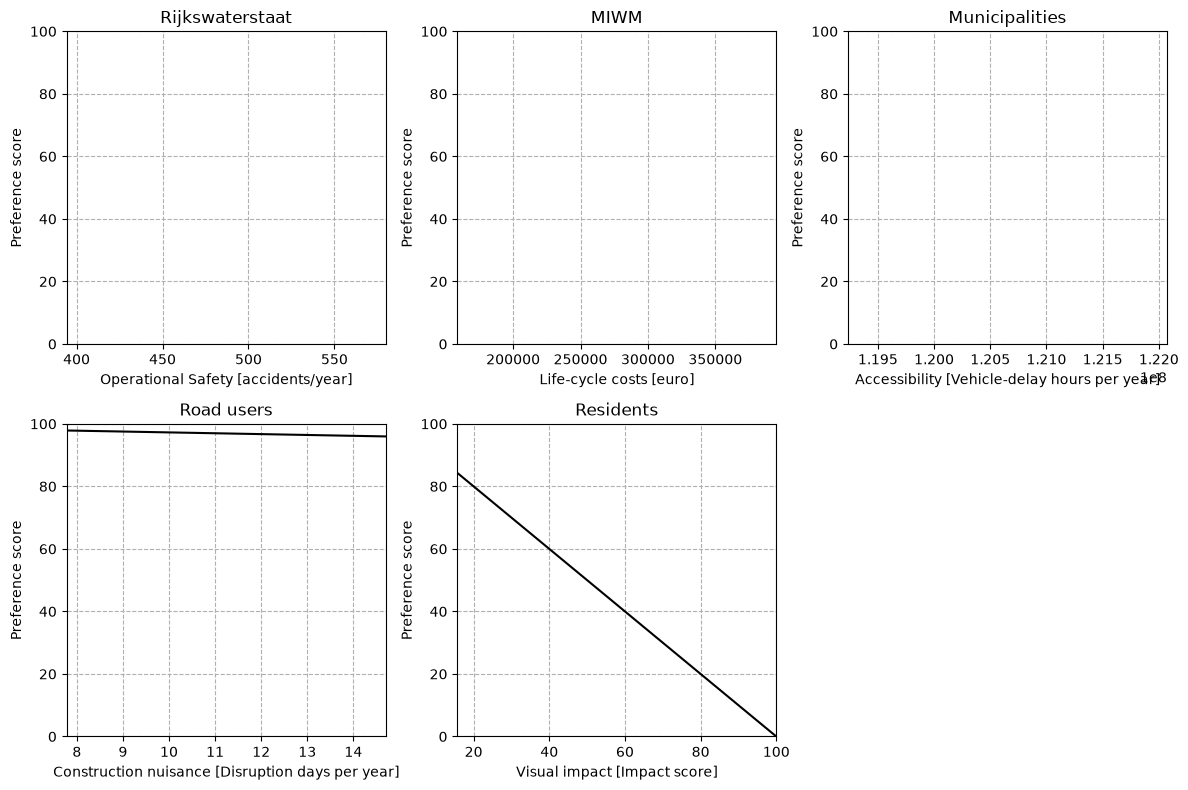

In [30]:
# Define preferences
prefs_before = [[[0, 1, 4],                      [100, 50, 0]],       # preference expected accidents/year
                [[0, 350, 900, 4968],           [0, 100, 50, 0]],   # preference € in million
                [[0, 450],                      [100, 0]],          # preference Vehicle-delay hours/year
                [[0, 365],                      [100, 0]],          # preference Disruption days/year
                [[0, 100],                      [100, 0]],          # preference Impact score (0–100)
                [[0, 5],                        [100, 0]],          # preference accidents during construction
                [[0, 1000],                     [100, 0]]]          # preference Vessel-delay hours/year

pref_after = [[[150000, 2000000, 4250000],      [100, 80, 0]],
                [[8, 120, 350],                 [0, 60, 100]],
                [[0, 80000, 150000, 375000],    [0, 100, 50, 0]],
                [[2, 9.5],                      [100, 0]],
                [[12500000, 250000000],         [0, 100]]]

prefs = prefs_before  # set to which preferences to use


# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

axes.flat[-1].set_visible(False)  # hide empty 6th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2, x3, x4, x5, x6):
    cost = objective_function_1(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2, x3, x4, x5, x6):
    ride = objective_function_2(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[1][0], prefs[1][1], ride)

def pref_func_3(x1, x2, x3, x4, x5, x6):
    sed = objective_function_3(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[2][0], prefs[2][1], sed)

def pref_func_4(x1, x2, x3, x4, x5, x6):
    safe = objective_function_4(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[3][0], prefs[3][1], safe)

def pref_func_5(x1, x2, x3, x4, x5, x6):
    econ = objective_function_5(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[4][0], prefs[4][1], econ)

def pref_func_6(x1, x2, x3, x4, x5, x6):
    vessel = objective_function_6(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[5][0], prefs[5][1], vessel)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4, pref_func_5, pref_func_6]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]
    x6 = variables[:, 5]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4, x5, x6)
    p_2 = pref_func_2(x1, x2, x3, x4, x5, x6)
    p_3 = pref_func_3(x1, x2, x3, x4, x5, x6)
    p_4 = pref_func_4(x1, x2, x3, x4, x5, x6)
    p_5 = pref_func_5(x1, x2, x3, x4, x5, x6)
    p_6 = pref_func_6(x1, x2, x3, x4, x5, x6)

    
    return weights, [p_1, p_2, p_3, p_4, p_5, p_6]

## Optimisation

Now that everything is in place, we can run the optimisation. For more details on the available configuration options, see the docstring of `GeneticAlgorithm` (accessible via `help()`). Note that a genetic algorithm relies on randomness, so it is expected that results will differ slightly between separate executions.

The optimisation can be run using three aggregation methods: `'minmax'`, `'a-fine'`, and optionally `'tetra'`. These methods differ in how the individual preference scores are combined into a group preference during the optimisation process; see `aggregations.md` for more information on how each method works and when to use it. These methods determine, mathematically, what is considered the "best" group preference. However, what is considered "best" is not purely a mathematical question, it also involves a qualitative judgement about which outcome is most appropriate for the problem at hand.

After computing the optimal results, the solutions are plotted on top of their corresponding preference curves.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results


AssertionError: Sum of weights should be equal to 1

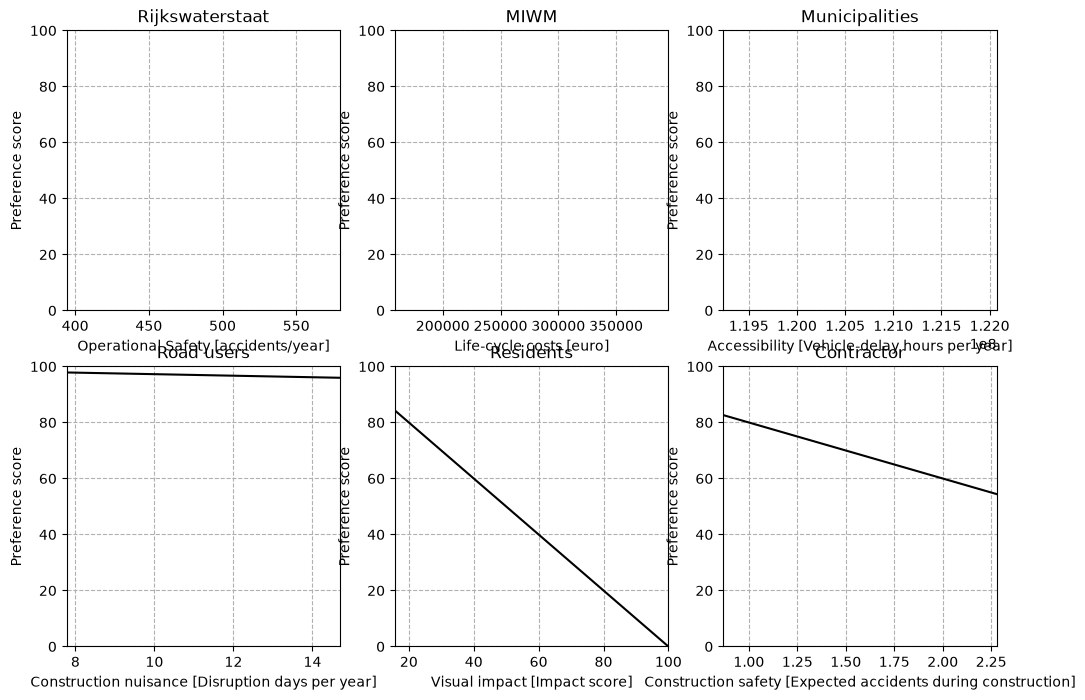

In [31]:
# We run the optimization with two paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*']
colours  = ['orange', 'green']

# Define the figure and axes before the loop
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run with the IMAP solver
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var) # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var) # Calculate resulting preference score
    
        # Print and plot the optimal point on the preference curve
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:5]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:5]:
    ax.legend(fontsize=10)

axes.flat[-1].set_visible(False)  # hide the sixth empty subplot


# Adjust the layout 
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()